In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_theme(style="whitegrid")
mpg = sns.load_dataset("mpg")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
mpg_clean = mpg.dropna(subset=["horsepower"])
print("Rows before cleaning:", len(mpg))
print("Rows after cleaning:", len(mpg_clean))

Rows before cleaning: 398
Rows after cleaning: 392


**Create a visual showing the relationship between horsepower and fuel economy.

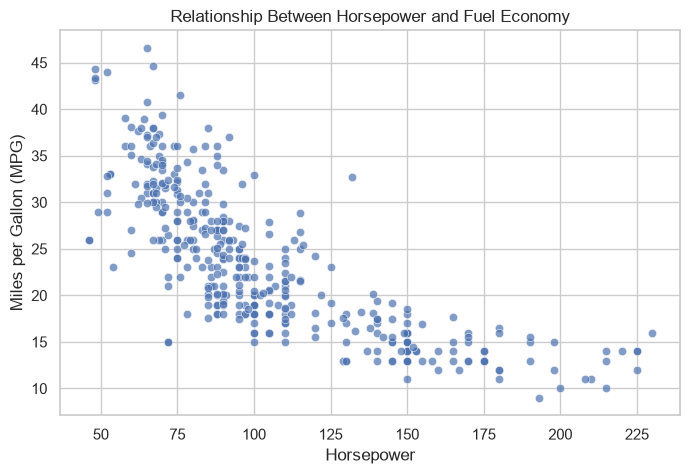

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=mpg_clean,x="horsepower",y="mpg",alpha=0.7)
plt.title("Relationship Between Horsepower and Fuel Economy")
plt.xlabel("Horsepower")
plt.ylabel("Miles per Gallon (MPG)")
plt.show()

The scatter plot shows a clear negative relationship between horsepower and fuel economy. In general, vehicles with higher horsepower tend to have lower MPG, while vehicles with lower horsepower tend to achive better fuel efficiency. There is some variation among vehicles, but the overall trend is consistent.

**Create a table summarizing fuel economy by country of origin

In [7]:
mpg.groupby('origin')['mpg'].mean().reset_index()

,origin,mpg
0,europe,27.891429
1,japan,30.450633
2,usa,20.083534


**Create a visual showing how fuel economy has changed over time

<Figure size 800x500 with 0 Axes>

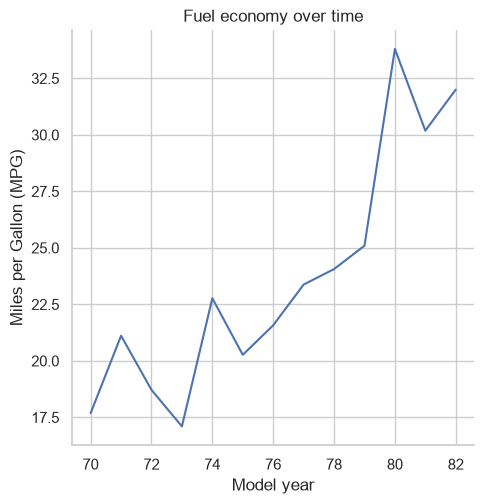

In [35]:
plt.figure(figsize=(8, 5))
sns.relplot(
data=mpg_clean,
x="model_year",
y="mpg",
kind="line",errorbar=None)
plt.title("Fuel economy over time")
plt.xlabel("Model year")
plt.ylabel("Miles per Gallon (MPG)")
plt.show()

The data shows an overall trend toward greater fuel efficiency in cars over the years, suggesting that vehicles have become more economical in their fuel consumption.

**Create two other visuals or tables related to fuel economy.

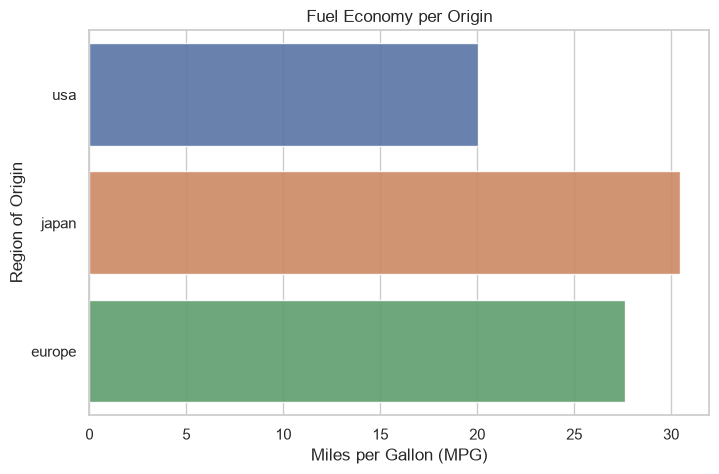

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(
data=mpg_clean,
x="mpg",
y="origin",
palette='deep',
hue="origin",
alpha=0.9,
errorbar=None,legend=False)
plt.title("Fuel Economy per Origin")
plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Region of Origin")
plt.show()

This visualization compares the average fuel efficiency of cars by region of origin. The results show that Japan produces cars with the highest average fuel economy, suggesting that Japanese-made vehicles are generally more fuel-efficient than vehicles produced in other regions.

In [29]:
mpg_clean['manufacturer'] = 'Other'
mpg_clean.loc[mpg_clean['name'].str.contains('ford', case=False, na=False), 'manufacturer'] = 'Ford'
mpg_clean.loc[mpg_clean['name'].str.contains('chevrolet|chevy', case=False, na=False), 'manufacturer'] = 'Chevrolet'
mpg_clean.loc[mpg_clean['name'].str.contains('toyota', case=False, na=False), 'manufacturer'] = 'Toyota'
mpg_clean.loc[mpg_clean['name'].str.contains('honda', case=False, na=False), 'manufacturer'] = 'Honda'
mpg_clean.loc[mpg_clean['name'].str.contains('dodge', case=False, na=False), 'manufacturer'] = 'Dodge'
mpg_clean.loc[mpg_clean['name'].str.contains('volkswagen|vw', case=False, na=False), 'manufacturer'] = 'Volkswagen'
mpg_clean.loc[mpg_clean['name'].str.contains('buick', case=False, na=False), 'manufacturer'] = 'Buick'
mpg_clean.loc[mpg_clean['name'].str.contains('pontiac', case=False, na=False), 'manufacturer'] = 'Pontiac'
mpg_clean.loc[mpg_clean['name'].str.contains('plymouth', case=False, na=False), 'manufacturer'] = 'Plymouth'
mpg_clean.loc[mpg_clean['name'].str.contains('mazda', case=False, na=False), 'manufacturer'] = 'Mazda'
mpg_clean.loc[mpg_clean['name'].str.contains('amc', case=False, na=False), 'manufacturer'] = 'AMC'
mpg_clean.loc[mpg_clean['name'].str.contains('datsun', case=False, na=False), 'manufacturer'] = 'Datsun'
mpg_clean.loc[mpg_clean['name'].str.contains('pontiac', case=False, na=False), 'manufacturer'] = 'Pontiac'
mpg_clean.loc[mpg_clean['name'].str.contains('oldmobile', case=False, na=False), 'manufacturer'] = 'Oldmobile'
manufacturer_mpg = (
    mpg_clean
    .groupby("manufacturer")["mpg"]
    .mean()
    .reset_index().sort_values("mpg", ascending=False)) 
manufacturer_mpg

,manufacturer,mpg
6,Honda,33.761538
12,Volkswagen,31.938095
3,Datsun,31.113043
7,Mazda,30.860000
11,Toyota,28.372000
8,Other,23.608046
4,Dodge,22.060714
9,Plymouth,21.703226
2,Chevrolet,20.310870
10,Pontiac,20.012500


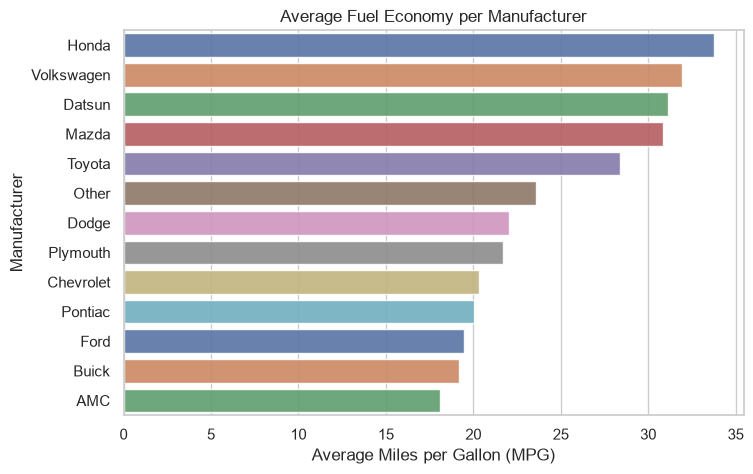

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=manufacturer_mpg, x="mpg",y="manufacturer",hue="manufacturer",
palette="deep",alpha=0.9,errorbar=None,legend=False)
plt.title("Average Fuel Economy per Manufacturer")
plt.xlabel("Average Miles per Gallon (MPG)")
plt.ylabel("Manufacturer")
plt.show()

This bar chart compares the average fuel economy (MPG) across different vehicle manufacturers. Honda has the highest average fuel economy at approximately 34 MPG, followed by Volkswagen, Datsun, Mazda, and Toyota. At the lower end, AMC has the lowest average at about 18 MPG. Overall, the visualization shows a clear difference in fuel efficiency among manufacturers, with several Japanese and European manufacturers showing higher average MPG than many American manufacturers.